# 10 Frames and Topology

Frame topology is a graph/path problem. Edge payloads are separate: topology says frames are connected; payloads say how to transform along edges.


## Imports

Imports are kept separate so the instructional cells can focus on TAL semantics.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tal import AnalysisObject
from tal.frames import (
    FrameGraph,
    FrameGraphDrawOptions,
    draw_frame_graph,
    find_path,
    fold_path,
    get_or_create_frame,
)
from tal.spatial import PathSolveOptions, Pose, Position, Rotation, solve_pose_path_transform
from tal.utils.frame_ops import frame_bind, frame_ids, frame_retag

from pathlib import Path
import sys

_release_dir = Path.cwd()
if not (_release_dir / '_helpers.py').exists():
    candidate = Path.cwd() / 'examples' / 'release'
    if candidate.exists():
        _release_dir = candidate
if str(_release_dir) not in sys.path:
    sys.path.append(str(_release_dir))

from _helpers import (
    build_framegraph_spatial_payloads,
    build_topology_edge_payloads,
    compact_dataset,
    display_result,
    explain_expected_failure,
    make_imu_gps_alignment_aos,
    make_kinematics_demo_objects,
    make_pose_demo_objects,
    show_ao,
    summarize_ao,
)


## Find and fold a path

This first fold sums float edge values. It is pedagogical, but it uses the same path traversal pattern as spatial path solving.


In [2]:
with FrameGraph() as graph:
    world = get_or_create_frame('world')
    body = get_or_create_frame('body', parent=world)
    sensor = get_or_create_frame('sensor', parent=body)

    path = find_path(sensor, world)
    edge_lengths = {('sensor', 'body'): 1.0, ('body', 'world'): 2.0}
    total = fold_path(
        path,
        edge_value_fn=lambda child, parent: edge_lengths[(child.id, parent.id)],
        compose=lambda acc, item: acc + item,
        inverse=lambda item: item,
        identity=lambda: 0.0,
    )

print('path nodes:', [f.id for f in path.nodes])
print('folded edge sum:', total)


path nodes: ['sensor', 'body', 'world']
folded edge sum: 3.0


## Optional graph visualization

Drawing is an optional dependency surface. The important semantic check is path direction: forward vs reverse traversal.


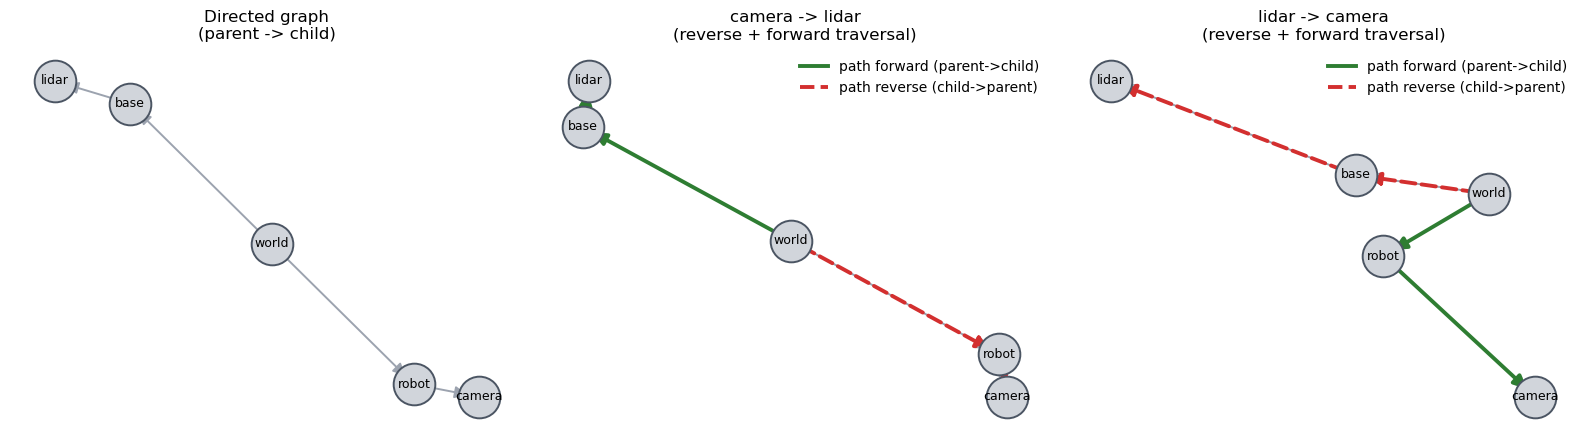

In [3]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("Visualization examples require matplotlib + networkx (optional deps).")

if plt is not None:
    try:
        with FrameGraph() as viz_graph:
            world = viz_graph.get_or_create_frame('world')
            robot = viz_graph.get_or_create_frame('robot', parent=world)
            camera = viz_graph.get_or_create_frame('camera', parent=robot)
            base = viz_graph.get_or_create_frame('base', parent=world)
            lidar = viz_graph.get_or_create_frame('lidar', parent=base)

            opts = FrameGraphDrawOptions(
                layout='spring',
                include_legend=True,
                path_forward_color='#2E7D32',
                path_reverse_color='#D32F2F',
            )

            fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

            draw_frame_graph(graph=viz_graph, opts=opts, ax=axes[0])
            axes[0].set_title('Directed graph\n(parent -> child)')

            draw_frame_graph(graph=viz_graph, src='camera', dst='lidar', opts=opts, ax=axes[1])
            axes[1].set_title('camera -> lidar\n(reverse + forward traversal)')

            draw_frame_graph(graph=viz_graph, src='lidar', dst='camera', opts=opts, ax=axes[2])
            axes[2].set_title('lidar -> camera\n(reverse + forward traversal)')

            fig.tight_layout()
    except ImportError as exc:
        print(exc)


## Seeded rendering and explicit path highlighting

Seeded rendering limits the displayed topology to a reachable domain. Explicit paths highlight the exact route being discussed.


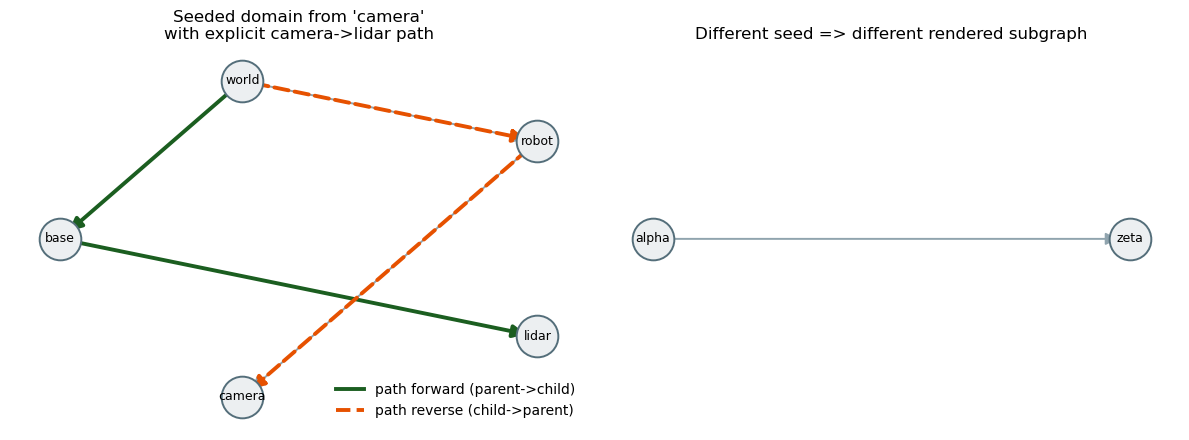

In [4]:
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("Visualization examples require matplotlib + networkx (optional deps).")

if plt is not None:
    try:
        with FrameGraph() as viz_graph:
            world = viz_graph.get_or_create_frame('world')
            robot = viz_graph.get_or_create_frame('robot', parent=world)
            camera = viz_graph.get_or_create_frame('camera', parent=robot)
            base = viz_graph.get_or_create_frame('base', parent=world)
            lidar = viz_graph.get_or_create_frame('lidar', parent=base)

            alpha = viz_graph.get_or_create_frame('alpha')
            viz_graph.get_or_create_frame('zeta', parent=alpha)

            explicit_path = find_path(camera, lidar)

            opts_seeded = FrameGraphDrawOptions(
                layout='shell',
                node_color='#ECEFF1',
                node_edge_color='#546E7A',
                edge_color='#90A4AE',
                path_forward_color='#1B5E20',
                path_reverse_color='#E65100',
                include_legend=True,
            )

            fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

            draw_frame_graph(
                graph=viz_graph,
                seeds=('camera',),
                include_unreachable=False,
                path=explicit_path,
                opts=opts_seeded,
                ax=axes[0],
            )
            axes[0].set_title("Seeded domain from 'camera'\nwith explicit camera->lidar path")

            draw_frame_graph(
                graph=viz_graph,
                seeds=('alpha',),
                include_unreachable=False,
                opts=opts_seeded,
                ax=axes[1],
            )
            axes[1].set_title("Different seed => different rendered subgraph")

            fig.tight_layout()
    except ImportError as exc:
        print(exc)


## Edge payloads are separate from topology

The graph does not store all transform data. Resolver functions supply edge payloads when a path solve needs them.


In [5]:
edge_sb, edge_bw = build_topology_edge_payloads()


Topology tells TAL which frames are connected. A small relative-layout plot gives the same relationship spatial intuition.

(np.float64(-0.027500000000000004),
 np.float64(0.5775),
 np.float64(-0.057499999999999996),
 np.float64(1.2075))

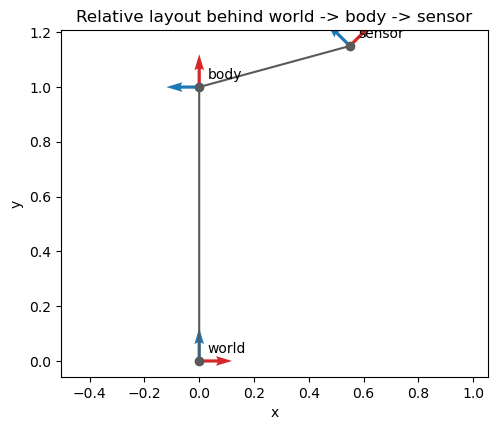

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
x = np.array([0.0, 0.0, 0.55])
y = np.array([0.0, 1.0, 1.15])
yaw = np.array([0.0, np.pi / 2.0, np.pi / 4.0])
labels = ['world', 'body', 'sensor']
ax.plot(x, y, 'o-', color='0.35')

axis_length = 0.12
for idx, label in enumerate(labels):
    c = float(np.cos(yaw[idx]))
    s = float(np.sin(yaw[idx]))
    ax.quiver(x[idx], y[idx], c, s, angles='xy', scale_units='xy', scale=1 / axis_length, color='tab:red')
    ax.quiver(x[idx], y[idx], -s, c, angles='xy', scale_units='xy', scale=1 / axis_length, color='tab:blue')
    ax.text(x[idx] + 0.03, y[idx] + 0.03, label)

ax.set(title='Relative layout behind world -> body -> sensor', xlabel='x', ylabel='y')
ax.axis('equal')


## Attach frame IDs to an AnalysisObject

Frame tags are object metadata. Binding connects those IDs to graph frames when you need topology-aware operations.


In [7]:
with FrameGraph() as graph:
    world = graph.get_or_create_frame('world')
    body = graph.get_or_create_frame('body', parent=world)
    sensor = graph.get_or_create_frame('sensor', parent=body)

    edge_map = {('sensor', 'body'): edge_sb, ('body', 'world'): edge_bw}

    solved = solve_pose_path_transform(
        sensor,
        world,
        edge_pose_fn=lambda child, parent: edge_map[(child.id, parent.id)],
        opts=PathSolveOptions(graph=graph),
    )

    probe_ds = xr.Dataset(
        data_vars={'position': (('sample', 'axis'), np.array([[1.0, 0.0, 0.0]], dtype=float))},
        coords={'sample': np.arange(1), 'axis': ['x', 'y', 'z']},
    )
    point_sensor = frame_retag(
        Position(AnalysisObject.from_data(probe_ds, sequence_dim='sample', core_dims=('axis',), validate=True)),
        parent='sensor',
        child='probe',
        validate=True,
    )
    point_world = point_sensor.to_frame(
        'world',
        edge_pose_fn=lambda child, parent: edge_map[(child.id, parent.id)],
        opts=PathSolveOptions(graph=graph),
        validate=True,
    )

print('solved pose frames:', frame_ids(solved))
print('point frames:', frame_ids(point_world))


solved pose frames: ('world', 'sensor')
point frames: ('world', 'probe')


In [8]:
base_ds = xr.Dataset(
    data_vars={'value': ('sample', np.array([1.0, 2.0, 3.0], dtype=float))},
    coords={'sample': np.arange(3)},
)
base = AnalysisObject.from_data(base_ds, sequence_dim='sample', core_dims=(), validate=True)
tagged = frame_retag(base, parent='world', child='camera', validate=True)

with FrameGraph() as graph:
    parent, child = frame_bind(tagged, graph=graph, create_missing=True, on_conflict='error')

print('metadata frame ids:', frame_ids(tagged))
print('bound frame ids:', (None if parent is None else parent.id, None if child is None else child.id))


metadata frame ids: ('world', 'camera')
bound frame ids: ('world', 'camera')


## Takeaways

- Topology and edge payloads are separate concerns.
- `find_path` determines the route.
- `fold_path` accumulates edge values along that route.
- AO frame tags identify relation metadata.

**Exercise:** add a `lidar` frame under `body` and find the path from `sensor` to `lidar`.
